# makemore Part 2 exercise

A character-level language model predicts a distribution for the next character from a fixed context. We stay inside one model family throughout:

`indices → shared embedding → flatten → one tanh hidden layer → logits`

The reference dev loss improves from `2.1701` to about `1.9536`. The useful lesson is the diagnosis that led there: remove information and representation bottlenecks, add capacity, then regularize and optimize it.

In [1]:
import copy
import math
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

%matplotlib inline
torch.set_float32_matmul_precision('high')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
if device.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))

device: cuda
GPU: NVIDIA GeForce RTX 5090 Laptop GPU


### Data, tokens, and training examples

`.` is both the padding/start symbol and the end-of-name target. A name of length `L` creates `L + 1` next-character examples, so the model learns both how names continue and when they stop.

> **Insight:** a count table needs up to `V^T` separate rows for context length `T`. A learned embedding and shared MLP reuse statistical strength across characters and contexts instead of treating every context as an unrelated case.

In [2]:
data_path = Path('names.txt')
assert data_path.exists(), f'Could not find {data_path.resolve()}'
words = data_path.read_text().splitlines()

chars = sorted(set(''.join(words)))
stoi = {ch: i + 1 for i, ch in enumerate(chars)}
stoi['.'] = 0
itos = {i: ch for ch, i in stoi.items()}
vocab_size = len(stoi)

print('number of names:', len(words))
print('number of unique names:', len(set(words)))
print('shortest / longest name:', min(map(len, words)), '/', max(map(len, words)))
print('vocabulary:', ''.join(itos[i] for i in range(vocab_size)))
print('vocab_size:', vocab_size)

number of names: 32033
number of unique names: 29494
shortest / longest name: 2 / 15
vocabulary: .abcdefghijklmnopqrstuvwxyz
vocab_size: 27


### Train, dev, test, and context

We preserve the lecture's seed `42` and 80/10/10 split so `2.1701` remains a comparable baseline. Split complete names before constructing character examples: otherwise fragments of one sequence could leak across splits.

- **Train** supplies gradients for parameters.
- **Dev** selects context, width, embedding size, regularization, optimizer, and schedule.
- **Test** is a final audit; repeatedly consulting it trains the experimenter on the test set even without backpropagation.

`block_size = 5` raises the model's information ceiling: no amount of width can recover characters that were never provided. Contexts 6 and 8 lowered train loss but not dev loss, so their extra information and parameters did not generalize here.

In [3]:
block_size = 5

def build_dataset(word_list):
    X, Y = [], []
    for word in word_list:
        context = [0] * block_size
        for ch in word + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    return torch.tensor(X, dtype=torch.long), torch.tensor(Y, dtype=torch.long)

split_rng = random.Random(42)
split_rng.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

print('train:', Xtr.shape, Ytr.shape)
print('dev:  ', Xdev.shape, Ydev.shape)
print('test: ', Xte.shape, Yte.shape)

train: torch.Size([182625, 5]) torch.Size([182625])
dev:   torch.Size([22655, 5]) torch.Size([22655])
test:  torch.Size([22866, 5]) torch.Size([22866])


In [4]:
for x, y in zip(Xtr[:12], Ytr[:12]):
    context = ''.join(itos[i] for i in x.tolist())
    print(f'{context} ---> {itos[y.item()]}')

..... ---> y
....y ---> u
...yu ---> h
..yuh ---> e
.yuhe ---> n
yuhen ---> g
uheng ---> .
..... ---> d
....d ---> i
...di ---> o
..dio ---> n
.dion ---> d


### Shape contracts and the final MLP

| quantity | lecture model | this notebook |
|---|---:|---:|
| context length | 3 | **5** |
| embedding dimensions per character | 10 | **24** |
| tanh hidden neurons | 200 | **1536** |
| hidden dropout | 0% | **15%** |

Follow axis meaning rather than individual neurons:

`(N,5) → (N,5,24) → (N,120) → (N,1536) → (N,27)`

`N` is the parallel batch axis; every row uses the same weights. Each layer only has to satisfy the next layer's input contract. Also track axis semantics, dtype, and broadcasting—not shape alone—because a wrong permutation can remain shape-compatible.

`C[index]` is mathematically the same as `one_hot(index) @ C`, but lookup avoids constructing and multiplying mostly zeros. The shared table lets learning about one occurrence update that character everywhere. In the lecture's 2-D plot, `aeiou` cluster because they are predictively substitutable, not because the model was given the linguistic concept “vowel.”

`emb.flatten(1)` expresses “keep batch, flatten features.” A compatible `view` can reinterpret the same storage without a copy; unlike `cat`, this is cheap. The zero-copy claim depends on compatible strides/contiguity.

#### Capacity needs regularization

The lecture model's train and dev losses were both high and close, a sign of underfitting. Longer context, a 24-D embedding, and 1536 hidden features remove those bottlenecks; once train loss falls faster than dev loss, the diagnosis changes to overfitting.

During training, 15% dropout computes approximately `m · h / 0.85`. A hidden feature cannot rely on the same neighbors always being present, which discourages fragile co-adaptation. At evaluation and sampling, dropout is disabled and all 1536 units are used.

> **Insight:** “large enough to fit, then regularize” is more useful than making the model small merely to prevent memorization. Without dropout the wider MLP reached about 2.00, but its train/dev gap was larger.

In [5]:
n_embd = 24
n_hidden = 1536
dropout_p = 0.15
output_init_std = 0.001

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        fan_in = block_size * n_embd
        self.C = nn.Embedding(vocab_size, n_embd)
        self.fc1 = nn.Linear(fan_in, n_hidden)
        self.fc2 = nn.Linear(n_hidden, vocab_size)

        # Healthy tanh activations and almost-uniform initial predictions.
        nn.init.normal_(self.C.weight, mean=0.0, std=1.0)
        nn.init.normal_(
            self.fc1.weight,
            mean=0.0,
            std=(5.0 / 3.0) / math.sqrt(fan_in),
        )
        nn.init.zeros_(self.fc1.bias)
        nn.init.normal_(self.fc2.weight, mean=0.0, std=output_init_std)
        nn.init.zeros_(self.fc2.bias)

    def forward(self, idx):
        emb = self.C(idx)                         # (B, 5, 24)
        x = emb.flatten(1)                       # (B, 120)
        h = torch.tanh(self.fc1(x))              # (B, 1536)
        h = F.dropout(h, p=dropout_p, training=self.training)
        logits = self.fc2(h)                     # (B, 27)
        return logits

#### Initialization starts from reasonable ignorance

With 27 next-character classes, a model that knows nothing should begin near the uniform loss `log(27) = 3.29584`. Tiny output weights (`std=0.001`) and zero output bias produce near-zero logits instead of confident random mistakes.

The tanh layer uses gain `(5/3)/√fan_in` so activations are neither collapsed near zero nor mostly saturated at ±1. Initialization does not change what the MLP can represent; it changes whether gradient descent can reach a good solution efficiently.

In [6]:
seed = 2147483647
torch.manual_seed(seed)
if device.type == 'cuda':
    torch.cuda.manual_seed_all(seed)

model = MLP().to(device)
n_parameters = sum(p.numel() for p in model.parameters())
print(model)
print('number of parameters:', f'{n_parameters:,}')

MLP(
  (C): Embedding(27, 24)
  (fc1): Linear(in_features=120, out_features=1536, bias=True)
  (fc2): Linear(in_features=1536, out_features=27, bias=True)
)
number of parameters: 228,003


In [7]:
@torch.inference_mode()
def evaluate(model, X, Y, batch_size=16384):
    # model.eval() disables dropout.
    model.eval()
    total_nll = 0.0
    for start in range(0, len(X), batch_size):
        xb = X[start:start + batch_size].to(device)
        yb = Y[start:start + batch_size].to(device)
        logits = model(xb)
        total_nll += F.cross_entropy(logits, yb, reduction='sum').item()
    model.train()
    return total_nll / len(X)

initial_dev_loss = evaluate(model, Xdev, Ydev)
print('uniform loss:   ', math.log(vocab_size))
print('initial dev loss:', initial_dev_loss)

uniform loss:    3.295836866004329
initial dev loss: 3.296145908050099


### Optimization is part of the result

`F.cross_entropy(logits, targets)` expects raw logits. Compared with manually materializing `exp → probabilities → log`, it avoids unnecessary intermediate tensors, uses optimized forward/backward expressions, and evaluates log-sum-exp stably by shifting logits before exponentiation.

A uniformly sampled mini-batch gradient is a noisy estimate of the full gradient, not an unrelated direction. Batch 1024 trades more computation per update for lower variance and efficient matrix multiplication. Its loss is noisy but sufficient for updates; model selection uses full dev evaluation, not the latest batch loss.

The final recipe is AdamW with `betas=(0.9,0.99)`, weight decay `1e-4` on weight matrices and embeddings, 100-step warmup to `2e-3`, then cosine decay to `6e-5` over 7500 steps. Early large steps learn coarse structure; late small steps settle instead of bouncing. The lecture's logarithmic learning-rate sweep supplies the same underlying insight: too small barely learns, too large becomes unstable.

> **Training-loop invariant:** `backward()` accumulates into existing gradients, so `zero_grad(set_to_none=True)` before each new batch is essential unless accumulation is intentional. Evaluate every 500 steps and retain the best dev checkpoint.

In [8]:
batch_size = 1024
max_steps = 7500
eval_every = 500
peak_lr = 2e-3
warmup_steps = 100
floor_ratio = 0.03
weight_decay = 1e-4

decay, no_decay = [], []
for name, parameter in model.named_parameters():
    (no_decay if name.endswith('bias') else decay).append(parameter)

optimizer = torch.optim.AdamW(
    [
        {'params': decay, 'weight_decay': weight_decay},
        {'params': no_decay, 'weight_decay': 0.0},
    ],
    lr=peak_lr,
    betas=(0.9, 0.99),
    fused=(device.type == 'cuda'),
)

def learning_rate_at(step):
    if step < warmup_steps:
        return peak_lr * (step + 1) / warmup_steps
    ratio = (step - warmup_steps) / (max_steps - warmup_steps - 1)
    cosine = 0.5 * (1.0 + math.cos(math.pi * ratio))
    return peak_lr * (floor_ratio + (1.0 - floor_ratio) * cosine)

print('first / peak / final learning rate:')
print(learning_rate_at(0), learning_rate_at(warmup_steps - 1), learning_rate_at(max_steps - 1))

first / peak / final learning rate:
2e-05 0.002 6e-05


In [9]:
best_dev_loss = float('inf')
best_step = -1
best_state = None
lossi = []
lri = []
started = time.time()

model.train()
for step in range(max_steps):
    lr = learning_rate_at(step)
    for group in optimizer.param_groups:
        group['lr'] = lr

    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    xb = Xtr[ix].to(device)
    yb = Ytr[ix].to(device)

    logits = model(xb)
    loss = F.cross_entropy(logits, yb)

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

    lossi.append(loss.item())
    lri.append(lr)

    should_evaluate = (step == 0 or (step + 1) % eval_every == 0 or step + 1 == max_steps)
    if should_evaluate:
        dev_loss = evaluate(model, Xdev, Ydev)
        if dev_loss < best_dev_loss:
            best_dev_loss = dev_loss
            best_step = step + 1
            best_state = copy.deepcopy(
                {name: tensor.detach().cpu() for name, tensor in model.state_dict().items()}
            )
        print(
            f'step {step + 1:4d}/{max_steps} | lr {lr:.6f} | '
            f'batch {loss.item():.4f} | dev {dev_loss:.6f} | '
            f'best {best_dev_loss:.6f} @ {best_step} | '
            f'{time.time() - started:.1f}s'
        )

step    1/7500 | lr 0.000020 | batch 3.2969 | dev 3.289406 | best 3.289406 @ 1 | 0.1s


step  500/7500 | lr 0.001986 | batch 2.1510 | dev 2.118045 | best 2.118045 @ 500 | 2.8s


step 1000/7500 | lr 0.001930 | batch 1.9501 | dev 2.066199 | best 2.066199 @ 1000 | 5.8s


step 1500/7500 | lr 0.001834 | batch 1.9375 | dev 2.057344 | best 2.057344 @ 1500 | 8.0s


step 2000/7500 | lr 0.001701 | batch 1.9000 | dev 2.053503 | best 2.053503 @ 2000 | 9.2s


...

step 5500/7500 | lr 0.000389 | batch 1.7687 | dev 1.967932 | best 1.967932 @ 5500 | 27.8s


step 6000/7500 | lr 0.000250 | batch 1.8672 | dev 1.964988 | best 1.964988 @ 6000 | 30.0s


step 6500/7500 | lr 0.000146 | batch 1.7567 | dev 1.961569 | best 1.961569 @ 6500 | 32.9s


step 7000/7500 | lr 0.000082 | batch 1.7564 | dev 1.955367 | best 1.955367 @ 7000 | 36.0s


step 7500/7500 | lr 0.000060 | batch 1.8193 | dev 1.953603 | best 1.953603 @ 7500 | 38.3s


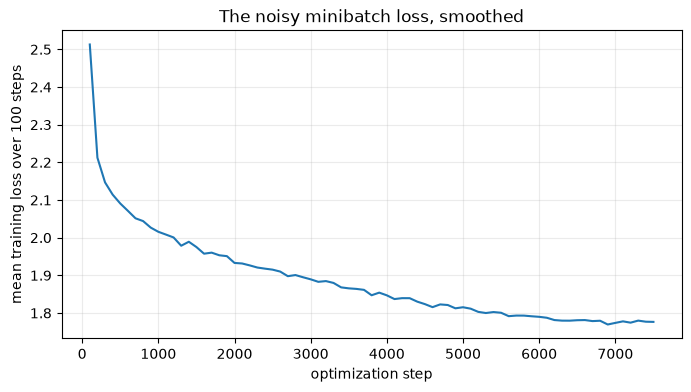

In [10]:
loss_tensor = torch.tensor(lossi)
window = 100
smoothed = loss_tensor.unfold(0, window, window).mean(1)
plt.figure(figsize=(8, 4))
plt.plot(torch.arange(len(smoothed)) * window + window, smoothed)
plt.xlabel('optimization step')
plt.ylabel(f'mean training loss over {window} steps')
plt.title('The noisy minibatch loss, smoothed')
plt.grid(alpha=0.25);

### Evaluation discipline

Restore the checkpoint chosen by dev loss, then evaluate test once. All values below are mean character-level negative log likelihood, including the end token. Repeatedly viewing test and changing the model would turn test into another dev set.

In [11]:
assert best_state is not None
model.load_state_dict(best_state)

train_loss = evaluate(model, Xtr, Ytr)
dev_loss = evaluate(model, Xdev, Ydev)
test_loss = evaluate(model, Xte, Yte)  # the one final test evaluation

baseline_dev_loss = 2.1701
print(f'best step: {best_step}')
print(f'train loss: {train_loss:.6f}')
print(f'dev loss:   {dev_loss:.6f}   perplexity: {math.exp(dev_loss):.4f}')
print(f'test loss:  {test_loss:.6f}   perplexity: {math.exp(test_loss):.4f}')
print(f'dev NLL improvement over 2.1701: {baseline_dev_loss - dev_loss:.6f}')
print(
    'dev perplexity reduction:',
    f'{100 * (math.exp(baseline_dev_loss) - math.exp(dev_loss)) / math.exp(baseline_dev_loss):.2f}%'
)

best step: 7500
train loss: 1.682963
dev loss:   1.953603   perplexity: 7.0541
test loss:  1.954022   perplexity: 7.0570
dev NLL improvement over 2.1701: 0.216497
dev perplexity reduction: 19.47%


#### Reading the result

| split | loss | perplexity |
|---|---:|---:|
| train | 1.6830 | 5.38 |
| dev | **1.9536** | **7.05** |
| test | **1.9540** | **7.06** |

Dev NLL improves by 0.2165, while perplexity falls from about 8.76 to 7.05 (19.5%). The remaining train/dev gap says the wide model still fits training data more closely; it does not erase the held-out improvement.

### Failed experiments are diagnostics

- Context 5 plus a less restrictive embedding produced the largest architectural gain; a 512-unit version without dropout already approached 2.00 dev loss.
- Wider hidden layers lowered train loss but enlarged the train/dev gap. Dropout made that capacity useful; 15% beat 5% and 10% for width 1536.
- Contexts 6/8 and a second hidden layer lowered train loss without improving dev. “More information” and “more expressive” are only benefits when finite data can support them and optimization can use them.
- Bengio's input→output shortcut sped an easy linear path but gave no stable dev gain; the hidden layer already represented those effects, and the version without the shortcut generalized slightly better.
- An n-gram mixture was excluded because it would stop being a pure single-MLP result.

> **Debugging habit:** first verify that a sufficiently large network can overfit a tiny batch. If it cannot, suspect data, targets, forward, gradients, or learning rate. Exact zero may still be impossible when an identical context legitimately has several next characters.

### Sampling reuses the same shape contract

Training maps `(N,5) → (N,27)`; generation maps `(1,5) → (1,27)`. Only the batch size changes. Start with five `.` tokens, sample from softmax with `multinomial`, shift the context, and stop at `.`. Sampling preserves diversity; argmax would repeatedly follow one path.

`model.eval()` disables dropout, while `inference_mode()` disables autograd—different responsibilities. Generated names are a qualitative sanity check, not a substitute for held-out NLL.

In [12]:
@torch.inference_mode()
def sample_names(model, count=20, seed=2147483657):
    model.eval()
    generator = torch.Generator(device=device).manual_seed(seed)
    samples = []
    for _ in range(count):
        context = torch.zeros((1, block_size), dtype=torch.long, device=device)
        out = []
        for _ in range(30):  # safety cap for an unusually long sample
            logits = model(context)
            probs = F.softmax(logits, dim=1)
            ix = torch.multinomial(probs, num_samples=1, generator=generator).item()
            if ix == 0:
                break
            out.append(ix)
            context = torch.cat(
                [context[:, 1:], torch.tensor([[ix]], device=device)], dim=1
            )
        samples.append(''.join(itos[i] for i in out))
    return samples

print('\n'.join(sample_names(model)))

brently
ezri
demari
jannard
sulee
fidzy
murphy
cancer
tradge
wylden
dmitri
kelcon
aarsh
taty
kengen
kamdra
raan
jullina
doria
davee


### Review mental model

The improvement follows a diagnostic sequence: train/dev both high means remove information, representation, or capacity bottlenecks; train falling while dev stalls means regularize rather than blindly scale. Initialization makes the first gradients sensible, and the schedule determines whether capacity becomes a trained solution.

For every network, keep four ledgers: **shape semantics**, **train versus dev behavior**, **optimization state**, and **which split informed each decision**. That abstraction scales much better than imagining individual neurons.

> **Data caveat:** 32,033 rows contain only 29,494 unique names, so the official split can place duplicates across splits. We retain it only for comparison with 2.1701; stricter evaluation would group or deduplicate names before splitting.

### Optional activation experiment: SiLU

`SiLU(x) = x · sigmoid(x)` is smooth and does not bound positive activations as tanh does. That changes activation statistics and effective capacity, so an activation swap is coupled to initialization, learning rate, and regularization—not a guaranteed free improvement.

This optional recipe keeps one hidden layer and 228,003 parameters but uses 50% dropout to control SiLU's stronger tendency to overfit here. It is a tuned recipe comparison, not a one-variable causal ablation; tanh with 15% dropout remains the main result.

In [13]:
silu_dropout_p = 0.50

class SiLUMLP(nn.Module):
    def __init__(self):
        super().__init__()
        fan_in = block_size * n_embd
        self.C = nn.Embedding(vocab_size, n_embd)
        self.fc1 = nn.Linear(fan_in, n_hidden)
        self.fc2 = nn.Linear(n_hidden, vocab_size)

        nn.init.normal_(self.C.weight, mean=0.0, std=1.0)
        # sqrt(2) / sqrt(fan_in) is a reasonable starting scale for SiLU.
        nn.init.normal_(
            self.fc1.weight, mean=0.0, std=math.sqrt(2.0) / math.sqrt(fan_in)
        )
        nn.init.zeros_(self.fc1.bias)
        nn.init.normal_(self.fc2.weight, mean=0.0, std=output_init_std)
        nn.init.zeros_(self.fc2.bias)

    def forward(self, idx):
        emb = self.C(idx)
        x = emb.flatten(1)
        h = F.silu(self.fc1(x))
        h = F.dropout(h, p=silu_dropout_p, training=self.training)
        return self.fc2(h)

In [14]:
silu_seed = 2147483647
torch.manual_seed(silu_seed)
if device.type == 'cuda':
    torch.cuda.manual_seed_all(silu_seed)

silu_model = SiLUMLP().to(device)
silu_decay, silu_no_decay = [], []
for name, parameter in silu_model.named_parameters():
    (silu_no_decay if name.endswith('bias') else silu_decay).append(parameter)

silu_optimizer = torch.optim.AdamW(
    [
        {'params': silu_decay, 'weight_decay': weight_decay},
        {'params': silu_no_decay, 'weight_decay': 0.0},
    ],
    lr=peak_lr,
    betas=(0.9, 0.99),
    fused=(device.type == 'cuda'),
)

# An independent generator makes the minibatch sequence reproducible.
silu_batch_generator = torch.Generator().manual_seed(silu_seed + 1)
print(silu_model)
print('number of parameters:', f'{sum(p.numel() for p in silu_model.parameters()):,}')
print('initial dev loss:', evaluate(silu_model, Xdev, Ydev))

SiLUMLP(
  (C): Embedding(27, 24)
  (fc1): Linear(in_features=120, out_features=1536, bias=True)
  (fc2): Linear(in_features=1536, out_features=27, bias=True)
)
number of parameters: 228,003
initial dev loss: 3.298406118958287


In [15]:
silu_best_dev_loss = float('inf')
silu_best_step = -1
silu_best_state = None
silu_started = time.time()

silu_model.train()
for step in range(max_steps):
    lr = learning_rate_at(step)
    for group in silu_optimizer.param_groups:
        group['lr'] = lr

    ix = torch.randint(
        0, Xtr.shape[0], (batch_size,), generator=silu_batch_generator
    )
    xb = Xtr[ix].to(device)
    yb = Ytr[ix].to(device)
    silu_loss = F.cross_entropy(silu_model(xb), yb)

    silu_optimizer.zero_grad(set_to_none=True)
    silu_loss.backward()
    silu_optimizer.step()

    should_evaluate = (
        step == 0 or (step + 1) % eval_every == 0 or step + 1 == max_steps
    )
    if should_evaluate:
        silu_current_dev = evaluate(silu_model, Xdev, Ydev)
        if silu_current_dev < silu_best_dev_loss:
            silu_best_dev_loss = silu_current_dev
            silu_best_step = step + 1
            silu_best_state = copy.deepcopy(
                {k: v.detach().cpu() for k, v in silu_model.state_dict().items()}
            )
        print(
            f'step {step + 1:4d}/{max_steps} | batch {silu_loss.item():.4f} | '
            f'dev {silu_current_dev:.6f} | best {silu_best_dev_loss:.6f} | '
            f'{time.time() - silu_started:.1f}s'
        )

silu_model.load_state_dict(silu_best_state)
silu_train_loss = evaluate(silu_model, Xtr, Ytr)
silu_dev_loss = evaluate(silu_model, Xdev, Ydev)
print('---')
print(f'tanh dev loss: {dev_loss:.6f}')
print(f'SiLU train loss: {silu_train_loss:.6f}')
print(f'SiLU dev loss:   {silu_dev_loss:.6f}')
print(f'SiLU - tanh:     {silu_dev_loss - dev_loss:+.6f}')

step    1/7500 | batch 3.3010 | dev 3.289587 | best 3.289587 | 0.0s


step  500/7500 | batch 2.1027 | dev 2.085167 | best 2.085167 | 2.7s


step 1000/7500 | batch 1.9832 | dev 2.043863 | best 2.043863 | 5.7s


step 1500/7500 | batch 1.9849 | dev 2.016915 | best 2.016915 | 7.9s


step 2000/7500 | batch 2.0097 | dev 2.001473 | best 2.001473 | 10.9s


...

step 5500/7500 | batch 1.9022 | dev 1.957019 | best 1.957019 | 29.9s


step 6000/7500 | batch 1.8472 | dev 1.955181 | best 1.955181 | 32.9s


step 6500/7500 | batch 1.8491 | dev 1.952864 | best 1.952864 | 36.0s


step 7000/7500 | batch 1.8132 | dev 1.951746 | best 1.951746 | 39.0s


step 7500/7500 | batch 1.8237 | dev 1.951556 | best 1.951556 | 42.1s
---
tanh dev loss: 1.953603
SiLU train loss: 1.739852
SiLU dev loss:   1.951556
SiLU - tanh:     -0.002047


#### activation experiment

SiLU plus 50% dropout is only about **0.002–0.004 NLL** better than tanh plus 15% dropout across the checked seeds. The repeatable direction is encouraging, but the scale is tiny beside the gains from context, representation, width, and regularization.

> **Insight:** a modern activation is not automatically better, and changing it can change the optimal regularization. We do not inspect SiLU test loss because the optional recipe was selected on dev.